
---
# **CS5710 Assessed Coursework – Project**
### Student ID: 101113890


#### **Algorithms Implemented:**
1. K-Nearest Neighbors (KNN) - Instance-based classifier
2. Decision Tree - Tree-based classifier
3. Neural Network (MLP) - Multi-layer perceptron
4. Support Vector Machine (SVM) - Kernel-based classifier
5. Logistic Regression - Linear probabilistic classifier
6. K-Means Clustering - Unsupervised partitioning algorithm
---


## 1. ESSENTIAL LIBRARY IMPORTS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, silhouette_score, davies_bouldin_score)



## 2.LOADING DATASETS

In [2]:
print('\n' + '='*70)
print('DATASET 1: WHOLESALE CUSTOMER DATA')
print('='*70)

df_wholesale = pd.read_csv('Wholesale customers data.csv')
print(f'Shape: {df_wholesale.shape}')
print(f'Features: {list(df_wholesale.columns)}')
print(f'Missing values: {df_wholesale.isnull().sum().sum()}')
print(df_wholesale.head())


DATASET 1: WHOLESALE CUSTOMER DATA
Shape: (440, 8)
Features: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Missing values: 0
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [3]:
print('\n' + '='*70)
print('DATASET 2: HORTON GENERAL HOSPITAL')
print('='*70)

df_horton = pd.read_csv('HortonGeneralHospital.csv')
print(f'Original Shape: {df_horton.shape}')

if 'Unnamed: 0' in df_horton.columns:
    df_horton = df_horton.drop('Unnamed: 0', axis=1)

print(f'Cleaned Shape: {df_horton.shape}')
print(f'Features: {list(df_horton.columns)}')
print(df_horton.head())


DATASET 2: HORTON GENERAL HOSPITAL
Original Shape: (139, 7)
Cleaned Shape: (139, 6)
Features: ['Cardio', 'Resp', 'Hypo', 'Adm', 'year', 'month']
   Cardio  Resp  Hypo  Adm  year  month
0       1     0     0  413  1999     11
1       1     0     0  443  1999     12
2       1     0     0  378  2000      1
3       0     0     0  385  2000      2
4       1     0     0  388  2000      3


In [4]:
print('\n' + '='*70)
print('DATASET 3: BONGABDO METADATA')
print('='*70)

df_bongabdo = pd.read_csv('Bongabdo_Metadata.csv')
print(f'Shape: {df_bongabdo.shape}')
print(f'Features: {list(df_bongabdo.columns)}')
print(f'Missing values: {df_bongabdo.isnull().sum().sum()}')
print(df_bongabdo.head())


DATASET 3: BONGABDO METADATA
Shape: (111, 12)
Features: ['SN', 'Filename', 'Username', 'Age', 'Gender', 'Occupation', 'Category', 'Char Count', 'Article link', 'Strike', 'Bangla - English', 'Multi - Paragraph']
Missing values: 1
   SN           Filename Username  Age Gender Occupation          Category  \
0   1  IMG_20221226_0001     u000   25      M    Student     News - Travel   
1   2  IMG_20221226_0002     u001   27      F    Student  News - Lifestyle   
2   3  IMG_20221226_0003     u002   26      F    Student     News - Sports   
3   4  IMG_20221226_0004     u003   26      F    Student   News - Politics   
4   5  IMG_20221226_0005     u004   25      M    Student   News - Politics   

   Char Count                                       Article link  Strike  \
0       801.0  https://eisamay.indiatimes.com/lifestyle/news-...   False   
1       705.0  https://eisamay.indiatimes.com/lifestyle/food/...    True   
2       897.0  https://eisamay.com/sports/cricket/news/rahul-...    True 

## 3. DATA PREPERATION

In [5]:
print('DATASET 1: WHOLESALE CUSTOMERS')
print('-' * 70)

X_wholesale = df_wholesale.drop('Channel', axis=1)
y_wholesale = df_wholesale['Channel']

scaler_ws = StandardScaler()
X_wholesale_scaled = scaler_ws.fit_transform(X_wholesale)
X_wholesale_scaled = pd.DataFrame(X_wholesale_scaled, columns=X_wholesale.columns)

print(f'Features Shape: {X_wholesale_scaled.shape}')


DATASET 1: WHOLESALE CUSTOMERS
----------------------------------------------------------------------
Features Shape: (440, 7)


In [6]:
print('DATASET 2: HORTON HOSPITAL')
print('-' * 70)

X_horton = df_horton.drop('Cardio', axis=1)
y_horton = (df_horton['Cardio'] > df_horton['Cardio'].median()).astype(int)

scaler_ht = StandardScaler()
X_horton_scaled = scaler_ht.fit_transform(X_horton)
X_horton_scaled = pd.DataFrame(X_horton_scaled, columns=X_horton.columns)

print(f'Features Shape: {X_horton_scaled.shape}')

DATASET 2: HORTON HOSPITAL
----------------------------------------------------------------------
Features Shape: (139, 5)


In [7]:
print('DATASET 3: BONGABDO METADATA')
print('-' * 70)

df_bongabdo_clean = df_bongabdo.copy()
le_gender = LabelEncoder()
df_bongabdo_clean['Gender'] = le_gender.fit_transform(df_bongabdo_clean['Gender'])

# Create binary target from Strike column (convert boolean to int)
y_bongabdo = df_bongabdo_clean['Strike'].astype(int)

# Select numeric columns for features
numeric_cols = ['Age', 'Gender', 'Char Count']
X_bongabdo = df_bongabdo_clean[numeric_cols].copy()
X_bongabdo = X_bongabdo.fillna(X_bongabdo.mean())

scaler_bg = StandardScaler()
X_bongabdo_scaled = scaler_bg.fit_transform(X_bongabdo)
X_bongabdo_scaled = pd.DataFrame(X_bongabdo_scaled, columns=X_bongabdo.columns)

print(f'Features Shape: {X_bongabdo_scaled.shape}')

DATASET 3: BONGABDO METADATA
----------------------------------------------------------------------
Features Shape: (111, 3)


## 4.SPLITING DATASETS IN TRAIN AND TEST SET

In [8]:
X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_wholesale_scaled, y_wholesale, test_size=0.25, random_state=42, stratify=y_wholesale
)
print(f'Dataset 1 (Wholesale): Train={X_train_ws.shape[0]}, Test={X_test_ws.shape[0]}')

X_train_ht, X_test_ht, y_train_ht, y_test_ht = train_test_split(
    X_horton_scaled, y_horton, test_size=0.3, random_state=42, stratify=y_horton
)
print(f'Dataset 2 (Horton): Train={X_train_ht.shape[0]}, Test={X_test_ht.shape[0]}')

X_train_bg, X_test_bg, y_train_bg, y_test_bg = train_test_split(
    X_bongabdo_scaled, y_bongabdo, test_size=0.2, random_state=42, stratify=y_bongabdo
)
print(f'Dataset 3 (Bongabdo): Train={X_train_bg.shape[0]}, Test={X_test_bg.shape[0]}')


Dataset 1 (Wholesale): Train=330, Test=110
Dataset 2 (Horton): Train=97, Test=42
Dataset 3 (Bongabdo): Train=88, Test=23


## 5. ALGORITHM IMPLEMENTATION & TRAINING : KNN / DECISION TREE / MLP / SVM / LR / K-MEAN CLUSTER

In [9]:
# 1. K-Nearest Neighbors (KNN)
print('\n1. K-Nearest Neighbors (KNN) - k=5')
knn_ws = KNeighborsClassifier(n_neighbors=5).fit(X_train_ws, y_train_ws)
knn_ht = KNeighborsClassifier(n_neighbors=5).fit(X_train_ht, y_train_ht)
knn_bg = KNeighborsClassifier(n_neighbors=5).fit(X_train_bg, y_train_bg)

y_pred_knn_ws = knn_ws.predict(X_test_ws)
y_pred_knn_ht = knn_ht.predict(X_test_ht)
y_pred_knn_bg = knn_bg.predict(X_test_bg)

y_proba_knn_ws = knn_ws.predict_proba(X_test_ws)[:, 1]
y_proba_knn_ht = knn_ht.predict_proba(X_test_ht)[:, 1]
y_proba_knn_bg = knn_bg.predict_proba(X_test_bg)[:, 1]

# 2. Decision Tree
print('\n2. Decision Tree - max_depth=10')
dt_ws = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train_ws, y_train_ws)
dt_ht = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train_ht, y_train_ht)
dt_bg = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train_bg, y_train_bg)

y_pred_dt_ws = dt_ws.predict(X_test_ws)
y_pred_dt_ht = dt_ht.predict(X_test_ht)
y_pred_dt_bg = dt_bg.predict(X_test_bg)

y_proba_dt_ws = dt_ws.predict_proba(X_test_ws)[:, 1]
y_proba_dt_ht = dt_ht.predict_proba(X_test_ht)[:, 1]
y_proba_dt_bg = dt_bg.predict_proba(X_test_bg)[:, 1]

# 3. Neural Network (MLP)
print('\n3. Neural Network (MLP) - hidden_layers=(100,50)')
nn_ws = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42).fit(X_train_ws, y_train_ws)
nn_ht = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42).fit(X_train_ht, y_train_ht)
nn_bg = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42).fit(X_train_bg, y_train_bg)

y_pred_nn_ws = nn_ws.predict(X_test_ws)
y_pred_nn_ht = nn_ht.predict(X_test_ht)
y_pred_nn_bg = nn_bg.predict(X_test_bg)

y_proba_nn_ws = nn_ws.predict_proba(X_test_ws)[:, 1]
y_proba_nn_ht = nn_ht.predict_proba(X_test_ht)[:, 1]
y_proba_nn_bg = nn_bg.predict_proba(X_test_bg)[:, 1]

# 4. Support Vector Machine (SVM)
print('\n4. Support Vector Machine (SVM) - kernel=rbf')
svm_ws = SVC(kernel='rbf', probability=True, random_state=42).fit(X_train_ws, y_train_ws)
svm_ht = SVC(kernel='rbf', probability=True, random_state=42).fit(X_train_ht, y_train_ht)
svm_bg = SVC(kernel='rbf', probability=True, random_state=42).fit(X_train_bg, y_train_bg)

y_pred_svm_ws = svm_ws.predict(X_test_ws)
y_pred_svm_ht = svm_ht.predict(X_test_ht)
y_pred_svm_bg = svm_bg.predict(X_test_bg)

y_proba_svm_ws = svm_ws.predict_proba(X_test_ws)[:, 1]
y_proba_svm_ht = svm_ht.predict_proba(X_test_ht)[:, 1]
y_proba_svm_bg = svm_bg.predict_proba(X_test_bg)[:, 1]

# 5. Logistic Regression
print('\n5. Logistic Regression - solver=lbfgs')
lr_ws = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42).fit(X_train_ws, y_train_ws)
lr_ht = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42).fit(X_train_ht, y_train_ht)
lr_bg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42).fit(X_train_bg, y_train_bg)

y_pred_lr_ws = lr_ws.predict(X_test_ws)
y_pred_lr_ht = lr_ht.predict(X_test_ht)
y_pred_lr_bg = lr_bg.predict(X_test_bg)

y_proba_lr_ws = lr_ws.predict_proba(X_test_ws)[:, 1]
y_proba_lr_ht = lr_ht.predict_proba(X_test_ht)[:, 1]
y_proba_lr_bg = lr_bg.predict_proba(X_test_bg)[:, 1]

# 6. K-Means Clustering
print('\n6. K-Means Clustering - n_clusters=2')
kmeans_ws = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42).fit(X_train_ws)
kmeans_ht = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42).fit(X_train_ht)
kmeans_bg = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42).fit(X_train_bg)

kmeans_ws_pred = kmeans_ws.predict(X_test_ws)
kmeans_ht_pred = kmeans_ht.predict(X_test_ht)
kmeans_bg_pred = kmeans_bg.predict(X_test_bg)



1. K-Nearest Neighbors (KNN) - k=5

2. Decision Tree - max_depth=10

3. Neural Network (MLP) - hidden_layers=(100,50)

4. Support Vector Machine (SVM) - kernel=rbf

5. Logistic Regression - solver=lbfgs

6. K-Means Clustering - n_clusters=2


## 6. EVALUATION METRICS CALCULATION : KNN / DECISION TREE / MLP / SVM / LR 

In [10]:
def calculate_metrics(y_true, y_pred, y_proba, algo_name, data_name):
   
    try:
        auc_score = roc_auc_score(y_true, y_proba)
    except:
        auc_score = np.nan

    return {
        'Algorithm': algo_name,
        'Dataset': data_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': auc_score
    }

# Calculate all metrics
results = []

# KNN
results.append(calculate_metrics(y_test_ws, y_pred_knn_ws, y_proba_knn_ws, 'KNN', 'Wholesale'))
results.append(calculate_metrics(y_test_ht, y_pred_knn_ht, y_proba_knn_ht, 'KNN', 'Horton'))
results.append(calculate_metrics(y_test_bg, y_pred_knn_bg, y_proba_knn_bg, 'KNN', 'Bongabdo'))

# Decision Tree
results.append(calculate_metrics(y_test_ws, y_pred_dt_ws, y_proba_dt_ws, 'Decision Tree', 'Wholesale'))
results.append(calculate_metrics(y_test_ht, y_pred_dt_ht, y_proba_dt_ht, 'Decision Tree', 'Horton'))
results.append(calculate_metrics(y_test_bg, y_pred_dt_bg, y_proba_dt_bg, 'Decision Tree', 'Bongabdo'))

# Neural Network
results.append(calculate_metrics(y_test_ws, y_pred_nn_ws, y_proba_nn_ws, 'Neural Network', 'Wholesale'))
results.append(calculate_metrics(y_test_ht, y_pred_nn_ht, y_proba_nn_ht, 'Neural Network', 'Horton'))
results.append(calculate_metrics(y_test_bg, y_pred_nn_bg, y_proba_nn_bg, 'Neural Network', 'Bongabdo'))

# SVM
results.append(calculate_metrics(y_test_ws, y_pred_svm_ws, y_proba_svm_ws, 'SVM', 'Wholesale'))
results.append(calculate_metrics(y_test_ht, y_pred_svm_ht, y_proba_svm_ht, 'SVM', 'Horton'))
results.append(calculate_metrics(y_test_bg, y_pred_svm_bg, y_proba_svm_bg, 'SVM', 'Bongabdo'))

# Logistic Regression
results.append(calculate_metrics(y_test_ws, y_pred_lr_ws, y_proba_lr_ws, 'Logistic Regression', 'Wholesale'))
results.append(calculate_metrics(y_test_ht, y_pred_lr_ht, y_proba_lr_ht, 'Logistic Regression', 'Horton'))
results.append(calculate_metrics(y_test_bg, y_pred_lr_bg, y_proba_lr_bg, 'Logistic Regression', 'Bongabdo'))


## 7. COMPREHENSIVE RESULT TABLE

In [11]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

          Algorithm   Dataset  Accuracy  Precision   Recall  F1-Score      AUC
                KNN Wholesale  0.881818   0.887500 0.946667  0.916129 0.918857
                KNN    Horton  0.785714   0.000000 0.000000  0.000000 0.525735
                KNN  Bongabdo  0.608696   0.714286 0.416667  0.526316 0.625000
      Decision Tree Wholesale  0.900000   0.910256 0.946667  0.928105 0.873333
      Decision Tree    Horton  0.690476   0.222222 0.250000  0.235294 0.527574
      Decision Tree  Bongabdo  0.521739   0.555556 0.416667  0.476190 0.526515
     Neural Network Wholesale  0.900000   0.932432 0.920000  0.926174 0.910857
     Neural Network    Horton  0.690476   0.272727 0.375000  0.315789 0.544118
     Neural Network  Bongabdo  0.608696   0.666667 0.500000  0.571429 0.575758
                SVM Wholesale  0.890909   0.898734 0.946667  0.922078 0.952000
                SVM    Horton  0.809524   0.000000 0.000000  0.000000 0.433824
                SVM  Bongabdo  0.521739   0.571429 0

In [12]:
print(f'Best Accuracy: {results_df.loc[results_df["Accuracy"].idxmax()]["Algorithm"]} on {results_df.loc[results_df["Accuracy"].idxmax()]["Dataset"]} = {results_df["Accuracy"].max():.4f}')
print(f'Best Precision: {results_df.loc[results_df["Precision"].idxmax()]["Algorithm"]} on {results_df.loc[results_df["Precision"].idxmax()]["Dataset"]} = {results_df["Precision"].max():.4f}')
print(f'Best Recall: {results_df.loc[results_df["Recall"].idxmax()]["Algorithm"]} on {results_df.loc[results_df["Recall"].idxmax()]["Dataset"]} = {results_df["Recall"].max():.4f}')
print(f'Best F1-Score: {results_df.loc[results_df["F1-Score"].idxmax()]["Algorithm"]} on {results_df.loc[results_df["F1-Score"].idxmax()]["Dataset"]} = {results_df["F1-Score"].max():.4f}')

# Filter out NaN AUC values
results_df_valid_auc = results_df[results_df['AUC'].notna()]
if len(results_df_valid_auc) > 0:
    print(f'Best AUC: {results_df_valid_auc.loc[results_df_valid_auc["AUC"].idxmax()]["Algorithm"]} on {results_df_valid_auc.loc[results_df_valid_auc["AUC"].idxmax()]["Dataset"]} = {results_df_valid_auc["AUC"].max():.4f}')
else:
    print('AUC: Not available for all datasets')

Best Accuracy: Logistic Regression on Wholesale = 0.9091
Best Precision: Neural Network on Wholesale = 0.9324
Best Recall: KNN on Wholesale = 0.9467
Best F1-Score: Logistic Regression on Wholesale = 0.9342
Best AUC: SVM on Wholesale = 0.9520


## 8. VISUALIZATIONS

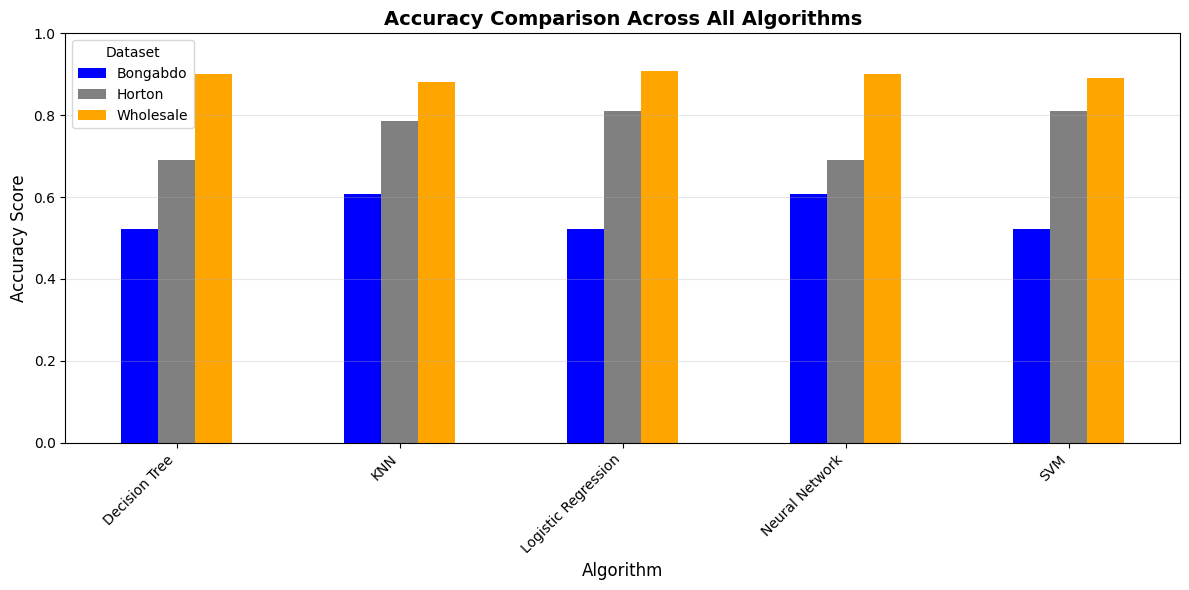

In [13]:
# Accuracy Comparison
acc_pivot = results_df.pivot_table(index='Algorithm', columns='Dataset', values='Accuracy', aggfunc='mean')
fig, ax = plt.subplots(figsize=(12, 6))
acc_pivot.plot(kind='bar', ax=ax, color=['blue', 'grey', 'orange'])
plt.title('Accuracy Comparison Across All Algorithms', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(title='Dataset')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

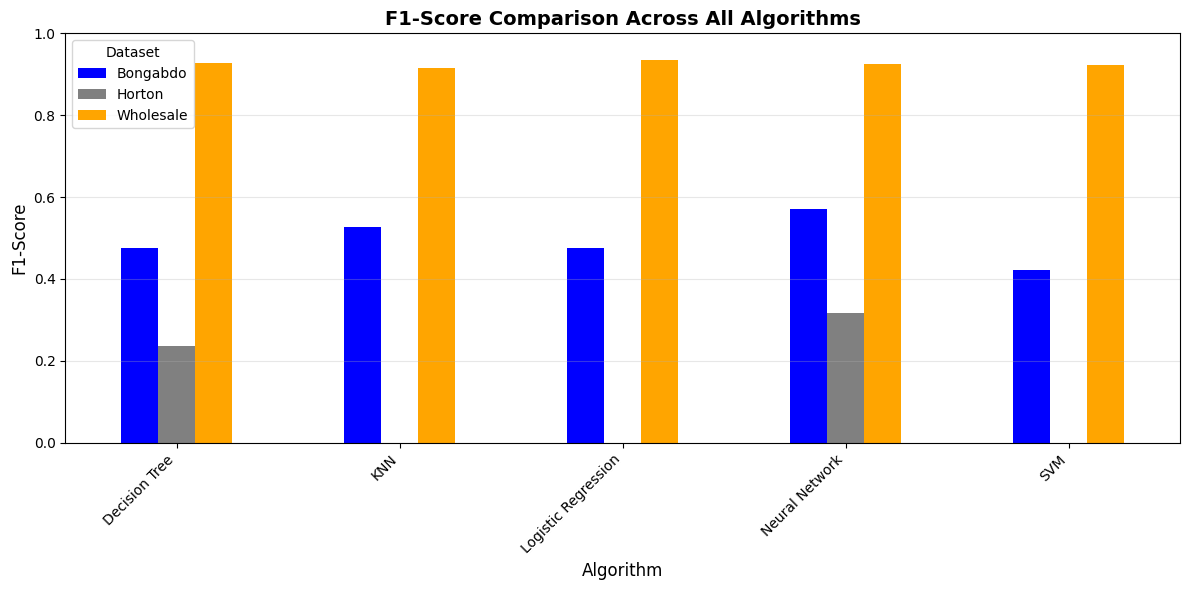

In [14]:
# F1-Score Comparison
f1_pivot = results_df.pivot_table(index='Algorithm', columns='Dataset', values='F1-Score', aggfunc='mean')
fig, ax = plt.subplots(figsize=(12, 6))
f1_pivot.plot(kind='bar', ax=ax, color=['blue', 'grey','orange'])
plt.title('F1-Score Comparison Across All Algorithms', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(title='Dataset')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. CLUSTERING EVALUATION: K-Means Metrics

In [15]:

silhouette_ws = silhouette_score(X_test_ws, kmeans_ws_pred)
silhouette_ht = silhouette_score(X_test_ht, kmeans_ht_pred)
silhouette_bg = silhouette_score(X_test_bg, kmeans_bg_pred)

davies_ws = davies_bouldin_score(X_test_ws, kmeans_ws_pred)
davies_ht = davies_bouldin_score(X_test_ht, kmeans_ht_pred)
davies_bg = davies_bouldin_score(X_test_bg, kmeans_bg_pred)

print('\nSilhouette Score (higher is better, range: -1 to 1):')
print(f' Wholesale: {silhouette_ws:.4f}')
print(f' Horton: {silhouette_ht:.4f}')
print(f' Bongabdo: {silhouette_bg:.4f}')

print('\nDavies-Bouldin Index (lower is better):')
print(f' Wholesale: {davies_ws:.4f}')
print(f' Horton: {davies_ht:.4f}')
print(f' Bongabdo: {davies_bg:.4f}')


Silhouette Score (higher is better, range: -1 to 1):
 Wholesale: 0.4372
 Horton: 0.1919
 Bongabdo: 0.3227

Davies-Bouldin Index (lower is better):
 Wholesale: 1.3425
 Horton: 1.4030
 Bongabdo: 1.1165


## 10. CONFUSION MATRICES

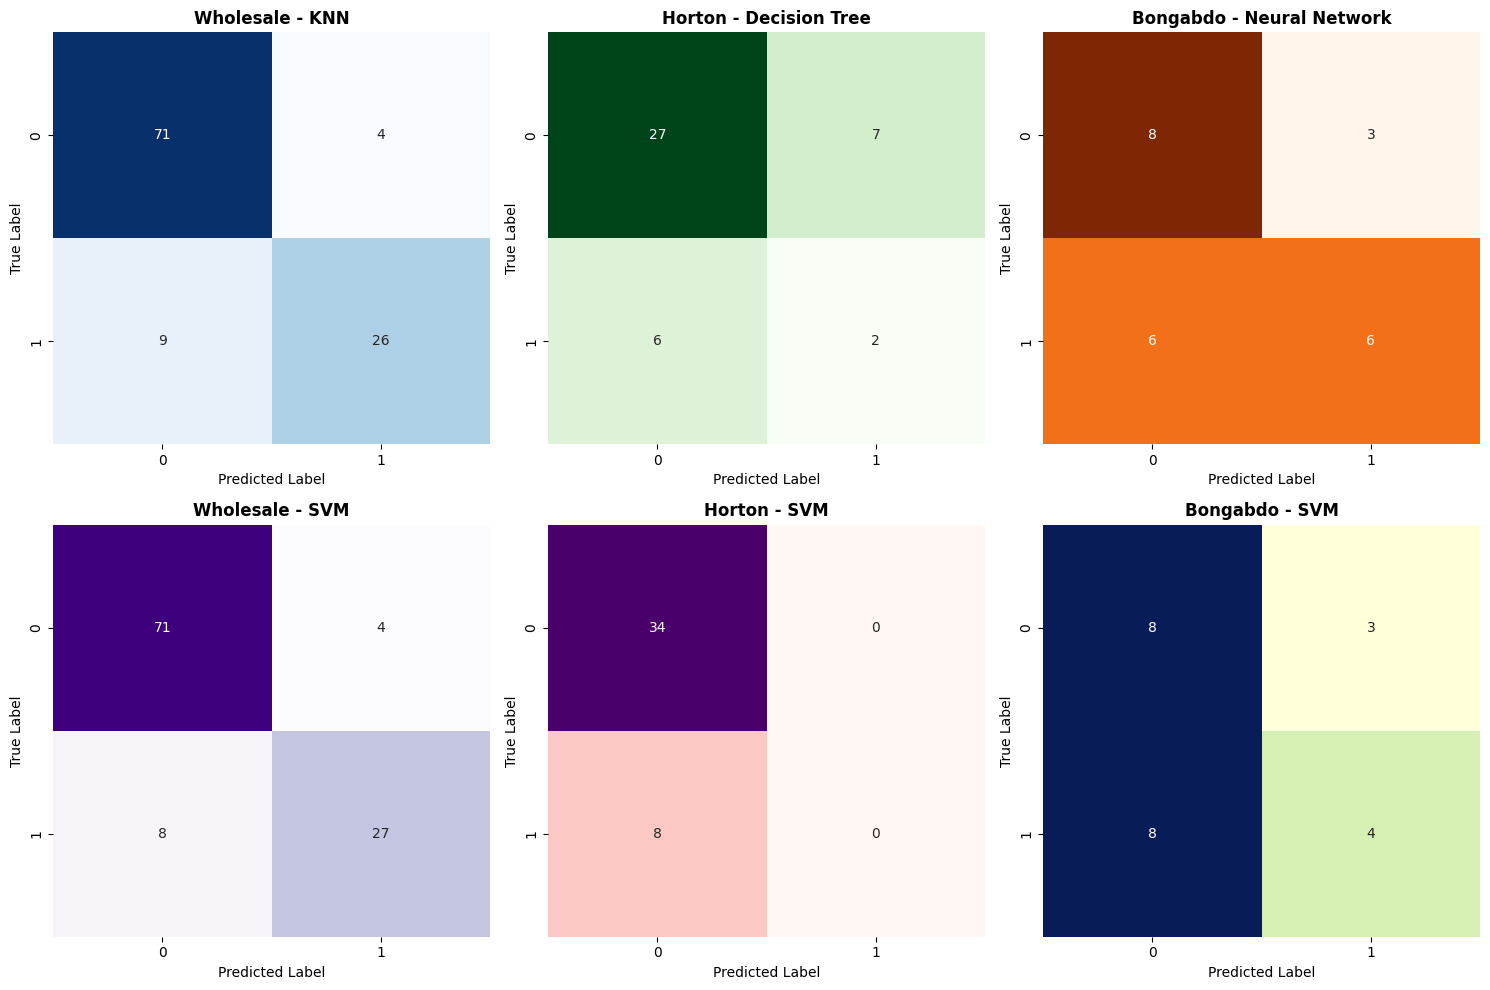

In [16]:

# Confusion matrices for best performing models per dataset
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Wholesale - KNN (best performer)
cm = confusion_matrix(y_test_ws, y_pred_knn_ws)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Wholesale - KNN', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Horton - Decision Tree (example)
cm = confusion_matrix(y_test_ht, y_pred_dt_ht)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Horton - Decision Tree', fontweight='bold')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Bongabdo - Neural Network (example)
cm = confusion_matrix(y_test_bg, y_pred_nn_bg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 2], cbar=False)
axes[0, 2].set_title('Bongabdo - Neural Network', fontweight='bold')
axes[0, 2].set_ylabel('True Label')
axes[0, 2].set_xlabel('Predicted Label')

# SVM models
cm = confusion_matrix(y_test_ws, y_pred_svm_ws)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('Wholesale - SVM', fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

cm = confusion_matrix(y_test_ht, y_pred_svm_ht)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Horton - SVM', fontweight='bold')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

cm = confusion_matrix(y_test_bg, y_pred_svm_bg)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1, 2], cbar=False)
axes[1, 2].set_title('Bongabdo - SVM', fontweight='bold')
axes[1, 2].set_ylabel('True Label')
axes[1, 2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---
# **MNIST Classification without scikit-learn**
---

**Dataset:** MNIST Handwritten Digits 

**Features:** 70,000 handwritten digit images (28×28 pixels)

### Algorithms Implemented without scikit-learn:

1. K-Nearest Neighbors (KNN) - Custom distance-based classifier
2. Decision Tree - Custom recursive tree builder with entropy-based splits
3. Logistic Regression - Custom gradient descent implementation
4. Multi-Layer Perceptron (MLP) - Custom neural network with backpropagation
---

## 1. ESSENTIAL LIBRARIES

In [17]:
from collections import Counter
from typing import Tuple, List
import time

#random number seed
np.random.seed(42)

## 2. MNIST Dataset Load

In [18]:
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

#subset for faster training 
X_train = X_train_full[:10000]
y_train = y_train_full[:10000]
X_test = X_test_full[:2000]
y_test = y_test_full[:2000]

print(f"Training labels shape: {y_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training labels shape: (10000,)
Test set shape: (2000, 28, 28)
Test labels shape: (2000,)


## 3. DATA PREPARATION

In [19]:
#conversion into dimensional vector 
X_train_flat=X_train.reshape(X_train.shape[0],-1)
X_test_flat=X_test.reshape(X_test.shape[0],-1)

#Normalize pixels into [0 1]
X_train_norm=X_train_flat/255.0
X_test_norm=X_test_flat/255.0

#subset of train and test set
X_train_proc = X_train_norm[:5000]
y_train_proc = y_train[:5000]
X_test_proc = X_test_norm[:1000]
y_test_proc = y_test[:1000]


## 4.ALGORITHM IMPLEMENTATION

### **K-NEAREST NEIGHBORS**

In [20]:
#KNN implementation on custom knn 

class CustomKNN:
    def __init__ (self, k=5):
        self.k=k
        self.X_train=None
        self.y_train=None

    def fit (self, X_train, y_train):
        self.X_train=X_train
        self.y_train=y_train
        return self

    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict_single (self,x):
        distance=np.array([self.euclidean_distance(x, x_train) 
                             for x_train in self.X_train])
        
        #getiing index of k-nearest neighbours using k-argsort 
        k_indices=np.argsort(distance)[:self.k]

        #getting label for the same
        k_labels=self.y_train[k_indices]

        #return majority vote
        most_common = Counter(k_labels).most_common(1)[0][0]
        return most_common
    
    #for predication of classes of multiple sample
    def predict (self,X_test):
         return np.array([self.predict_single(x) for x in X_test])


### **DECISION TREE**

In [21]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature          # Feature to split on
        self.threshold = threshold      # Threshold value
        self.left = left               # Left subtree
        self.right = right             # Right subtree
        self.value = value             # Class value if leaf node

#custom decision tree building
class CustomDecisionTree:
    def __init__ (self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    
    def entropy(self, y):
        proportions = np.bincount(y) / len(y)
        return -np.sum([p * np.log2(p) for p in proportions if p > 0])
    
    def information_gain(self, parent, left_child, right_child):
        n = len(parent)
        n_left, n_right = len(left_child), len(right_child)
        if n_left == 0 or n_right == 0:
            return 0
        parent_entropy = self.entropy(parent)
        left_entropy = self.entropy(left_child)
        right_entropy = self.entropy(right_child)
        weighted_child_entropy = (n_left / n) * left_entropy + (n_right / n) * right_entropy
        return parent_entropy - weighted_child_entropy
    
    def best_split(self, X, y): #best feature and split
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        for feature in range(X.shape[1]):
            thresholds = np.percentile(X[:, feature], [25, 50, 75])
            for threshold in thresholds:
                left = y[X[:, feature] <= threshold]
                right = y[X[:, feature] > threshold]
                if len(left) == 0 or len(right) == 0:
                    continue
                gain = self.information_gain(y, left, right)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold
    
    def build_tree(self, X, y, depth=0):   #recursive build of desicion
        n_samples = len(y)
        n_classes = len(np.unique(y))
        if depth >= self.max_depth or n_samples < self.min_samples_split or n_classes == 1: #stoping criteria
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
        
        best_feature, best_threshold = self.best_split(X, y) #best split finding
        if best_feature is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
        
        left_mask = X[:, best_feature] <= best_threshold    #build left and right subtree
        right_mask = ~left_mask
        
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold,
                    left=left_subtree, right=right_subtree)
    
    #fitting parameter for decision tree build
    def fit(self, X, y):
        self.tree = self.build_tree(X, y)
        return self
    
    #traverse for single sample prediction
    def traverse_tree(self, x, node):    
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.traverse_tree(x, node.left)
        else:
            return self.traverse_tree(x, node.right)
        
    #prediction for multiple sample based on above algo
    def predict(self, X):
        return np.array([self.traverse_tree(x, self.tree) for x in X])


### **LOGISTIC REGRESSION WITH GRADIENT DESCENT**

In [22]:
class CustomLogisticRegression:
    
    def __init__ (self, learning_rate=0.01, n_iterations=1000, lambda_param=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_param = lambda_param
        self.classifiers = {}  # Stores weights and bias per class
        self.classes = None
    
    #Sigmoid activation function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit_binary(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize weights and bias
        weights = np.zeros(n_features)
        bias = 0.0
        
        # Gradient descent
        for _ in range(self.n_iterations):
            # Forward pass: compute predictions
            z = np.dot(X, weights) + bias
            predictions = self.sigmoid(z)
            
            # Compute gradients (with L2 regularization)
            error = predictions - y
            dw = (np.dot(X.T, error) + self.lambda_param * weights) / n_samples
            db = np.sum(error) / n_samples
            
            # Update weights and bias
            weights -= self.learning_rate * dw
            bias -= self.learning_rate * db
        
        return weights, bias
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        
        # Create binary labels: current class vs rest
        for class_label in self.classes:
            y_binary = (y == class_label).astype(int)
            
            # Fit binary classifier
            weights, bias = self.fit_binary(X, y_binary)
            self.classifiers[class_label] = (weights, bias)
        
        return self
    
    #Predict probability for each class
    def predict_proba(self, X):
        n_samples = X.shape[0]
        probabilities = np.zeros((n_samples, len(self.classes)))
        
        for i, class_label in enumerate(self.classes):
            weights, bias = self.classifiers[class_label]
            z = np.dot(X, weights) + bias
            probabilities[:, i] = self.sigmoid(z)
        
        # Normalize probabilities across classes
        row_sums = probabilities.sum(axis=1, keepdims=True)
        probabilities /= row_sums
        
        return probabilities
    
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes[np.argmax(probabilities, axis=1)]


### **MLP (NEURAL NETWORK)**

In [23]:
#Simple MLP with ReLU + softmax
class CustomMLP: 
    def __init__ (self, hidden_sizes=(128, 64), lr=0.01, iters=100, batch_size=32):
        self.hidden_sizes = hidden_sizes
        self.lr = lr
        self.iters = iters
        self.batch_size = batch_size
        self.weights = []
        self.biases = []
        self.classes = None

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)

    def init_w(self, in_dim, out_dim):
        limit = np.sqrt(6 / (in_dim + out_dim))
        return np.random.uniform(-limit, limit, (in_dim, out_dim))

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes)

        # one-hot
        Y = np.zeros((n_samples, n_classes))
        for i, c in enumerate(self.classes):
            Y[y == c, i] = 1

        # layer sizes and params
        layer_sizes = [n_features] + list(self.hidden_sizes) + [n_classes]
        self.weights = [self.init_w(layer_sizes[i], layer_sizes[i+1])
                        for i in range(len(layer_sizes) - 1)]
        self.biases = [np.zeros((1, layer_sizes[i+1]))
                       for i in range(len(layer_sizes) - 1)]

        for i in range(self.iters):
            idx = np.random.permutation(n_samples)
            X_shuf, Y_shuf = X[idx], Y[idx]

            # mini-batches
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                xb, yb = X_shuf[start:end], Y_shuf[start:end]

                a_list = [xb]
                z_list = []
                a = xb
                for i in range(len(self.weights) - 1):
                    z = a @ self.weights[i] + self.biases[i]
                    z_list.append(z)
                    a = self.relu(z)
                    a_list.append(a)
                z = a @ self.weights[-1] + self.biases[-1]
                z_list.append(z)
                out = self.softmax(z)
                a_list.append(out)

                # backward
                dz = out - yb
                for i in range(len(self.weights) - 1, -1, -1):
                    dw = a_list[i].T @ dz / len(xb)
                    db = dz.sum(axis=0, keepdims=True) / len(xb)

                    self.weights[i] -= self.lr * dw
                    self.biases[i] -= self.lr * db

                    if i > 0:
                        dz = (dz @ self.weights[i].T) * self.relu_deriv(z_list[i-1])

        return self

    def predict(self, X):
        a = X
        for i in range(len(self.weights) - 1):
            a = self.relu(a @ self.weights[i] + self.biases[i])
        out = self.softmax(a @ self.weights[-1] + self.biases[-1])
        return self.classes[out.argmax(axis=1)]


### **EVALUATION METRICS**

In [24]:
def calculate_metrics(y_true, y_pred, algorithm_name, dataset_name):
  
    # Accuracy
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    
    # Per-class metrics (macro average)
    classes = np.unique(y_true)
    precisions, recalls, f1_scores = [], [], []
    
    for c in classes:
        # One-vs-rest for class c
        yt = (y_true == c).astype(int)
        yp = (y_pred == c).astype(int)
        
        tp = np.sum((yt == 1) & (yp == 1))
        fp = np.sum((yt == 0) & (yp == 1))
        fn = np.sum((yt == 1) & (yp == 0))
        
        precision = tp / (tp + fp) if tp + fp > 0 else 0.0
        recall    = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
    
    precision_macro = np.mean(precisions)
    recall_macro    = np.mean(recalls)
    f1_macro        = np.mean(f1_scores)
    
    return {
        "Algorithm": algorithm_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision (Macro)": precision_macro,
        "Recall (Macro)": recall_macro,
        "F1-Score (Macro)": f1_macro,
    }


### **TRAINING AND EVALUATION ON ALGORITHMS**

In [25]:
results = []
predictions = {}

print("\n1.Training on K-Nearest Neighbors (k=5):")
start_time = time.time()
knn= CustomKNN (k=5)
knn.fit(X_train_proc, y_train_proc)
y_pred_knn = knn.predict(X_test_proc)
knn_time = time.time() - start_time
results.append(calculate_metrics(y_test_proc, y_pred_knn, 'KNN (k=5)', 'MNIST Subset'))
predictions['KNN'] = y_pred_knn
print(f"Training time: {knn_time:.2f}")
print(f"Accuracy: {results[-1]['Accuracy']:.4f}")

# 2. Decision Tree
print("\n2.Training on Decision Tree:")
start_time = time.time()
dt = CustomDecisionTree(max_depth=5, min_samples_split=5)
dt.fit(X_train_proc, y_train_proc)
y_pred_dt = dt.predict(X_test_proc)
dt_time = time.time() - start_time
results.append(calculate_metrics(y_test_proc, y_pred_dt, 'Decision Tree', 'MNIST Subset'))
predictions['DT'] = y_pred_dt
print(f"Training time: {dt_time:.2f}")
print(f"Accuracy: {results[-1]['Accuracy']:.4f}")

# 3. Logistic Regression
print("\n3.Training on Logistic Regression (gradient descent):")
start_time = time.time()
lr = CustomLogisticRegression(learning_rate=0.01, n_iterations=500, lambda_param=0.001)
lr.fit(X_train_proc, y_train_proc)
y_pred_lr = lr.predict(X_test_proc)
lr_time = time.time() - start_time
results.append(calculate_metrics(y_test_proc, y_pred_lr, 'Logistic Regression', 'MNIST Subset'))
predictions['LR'] = y_pred_lr
print(f"Training time: {lr_time:.2f}")
print(f"Accuracy: {results[-1]['Accuracy']:.4f}")

# 4. Multi-Layer Perceptron
print("\n4.Training on Neural Network MLP:")
start_time = time.time()
mlp = CustomMLP(hidden_sizes=(64, 32), lr=0.01, iters=50, batch_size=32)
mlp.fit(X_train_proc, y_train_proc)
y_pred_mlp = mlp.predict(X_test_proc)
mlp_time = time.time() - start_time
results.append(calculate_metrics(y_test_proc, y_pred_mlp, 'MLP (Custom NN)', 'MNIST Subset'))
predictions['MLP'] = y_pred_mlp
print(f"Training time: {mlp_time:.2f}")
print(f"Accuracy: {results[-1]['Accuracy']:.4f}")




1.Training on K-Nearest Neighbors (k=5):
Training time: 10.88
Accuracy: 0.9110

2.Training on Decision Tree:
Training time: 1.86
Accuracy: 0.6670

3.Training on Logistic Regression (gradient descent):
Training time: 4.52
Accuracy: 0.7940

4.Training on Neural Network MLP:
Training time: 1.11
Accuracy: 0.9140


### **COMPREHENSIVE RESULT COMPARISON**

In [26]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(f"\nHighest Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Algorithm']} = {results_df['Accuracy'].max():.4f}")
print(f"Highest Precision: {results_df.loc[results_df['Precision (Macro)'].idxmax(), 'Algorithm']} = {results_df['Precision (Macro)'].max():.4f}")
print(f"Highest Recall: {results_df.loc[results_df['Recall (Macro)'].idxmax(), 'Algorithm']} = {results_df['Recall (Macro)'].max():.4f}")
print(f"Highest F1-Score: {results_df.loc[results_df['F1-Score (Macro)'].idxmax(), 'Algorithm']} = {results_df['F1-Score (Macro)'].max():.4f}")


          Algorithm      Dataset  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
          KNN (k=5) MNIST Subset     0.911           0.912657        0.910861          0.909881
      Decision Tree MNIST Subset     0.667           0.686494        0.668201          0.660668
Logistic Regression MNIST Subset     0.794           0.800618        0.789279          0.787149
    MLP (Custom NN) MNIST Subset     0.914           0.912728        0.912887          0.912451

Highest Accuracy: MLP (Custom NN) = 0.9140
Highest Precision: MLP (Custom NN) = 0.9127
Highest Recall: MLP (Custom NN) = 0.9129
Highest F1-Score: MLP (Custom NN) = 0.9125


### **SAMPLE PREDICTIONS AND VISUALIZATION**

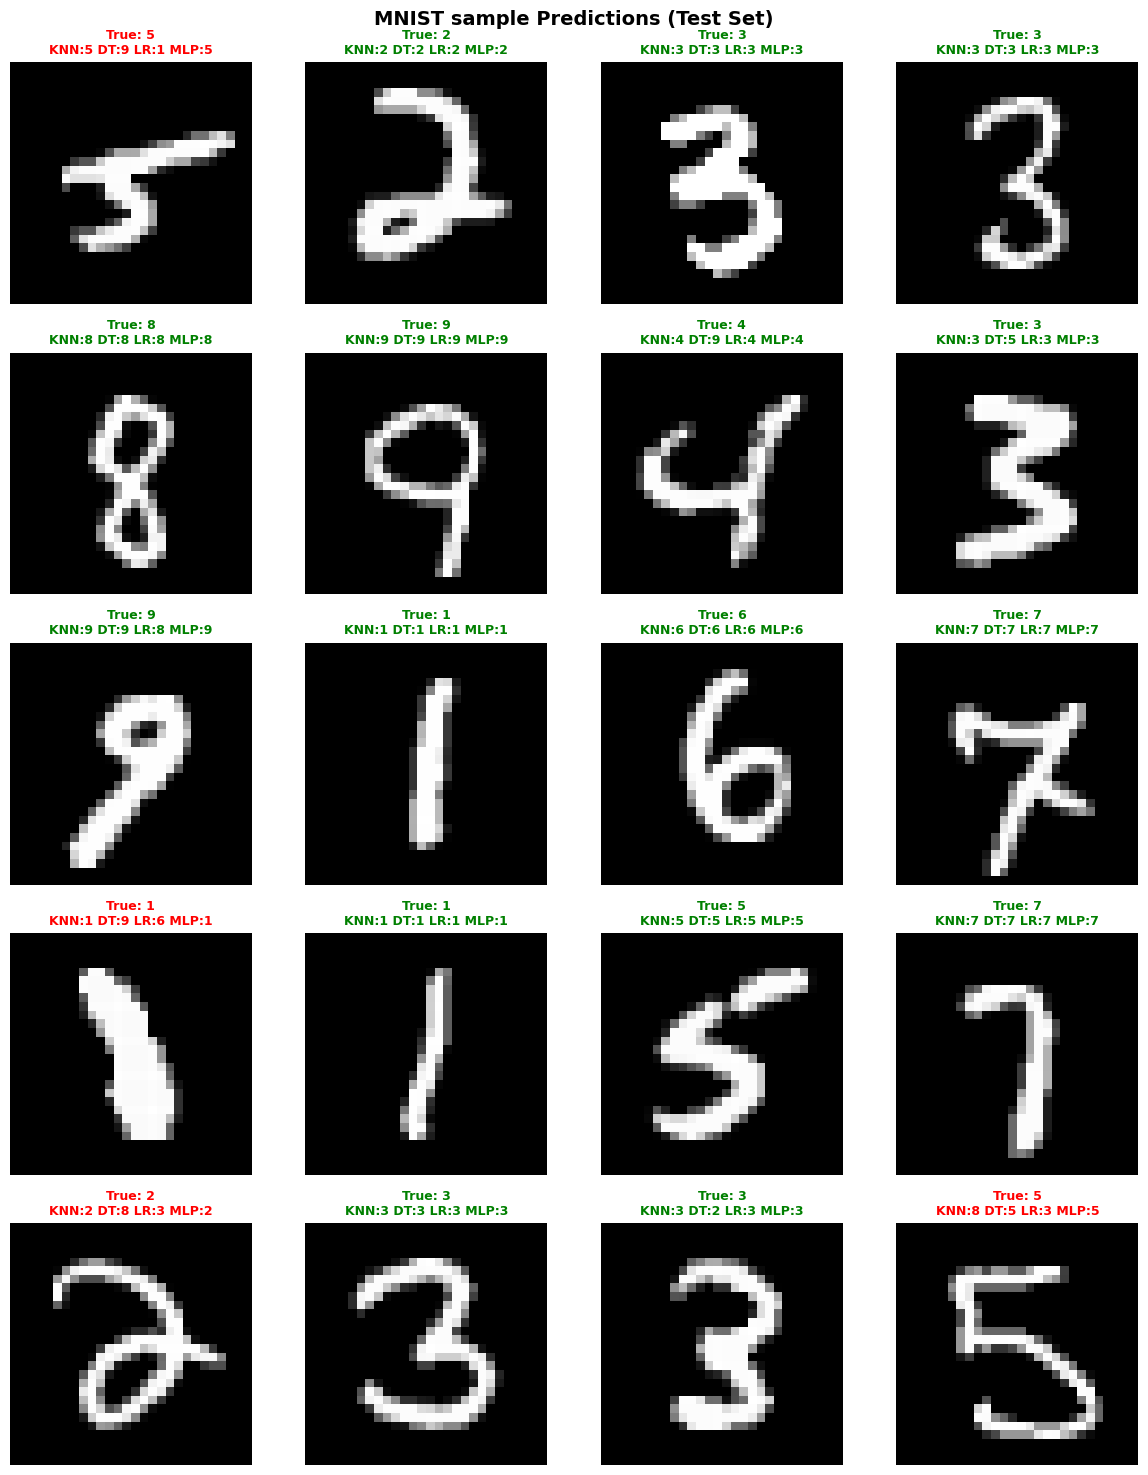

In [27]:
# Display sample predictions
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
fig.suptitle('MNIST sample Predictions (Test Set)', fontsize=14, fontweight='bold')

# Show 20 random test samples
sample_indices = np.random.choice(len(X_test_proc), 20, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    ax = axes[idx // 4, idx % 4]
    
    # Reshape and display image
    image = X_test_proc[sample_idx].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    
    # Get predictions from all classifiers
    true_label = y_test_proc[sample_idx]
    knn_pred = predictions['KNN'][sample_idx]
    dt_pred = predictions['DT'][sample_idx]
    lr_pred = predictions['LR'][sample_idx]
    mlp_pred = predictions['MLP'][sample_idx]
    
    # Determine color based on correctness
    correct_count = sum([knn_pred == true_label, dt_pred == true_label, 
                        lr_pred == true_label, mlp_pred == true_label])
    
    title_color = 'green' if correct_count >= 3 else 'red'
    
    title = f"True: {true_label}\nKNN:{knn_pred} DT:{dt_pred} LR:{lr_pred} MLP:{mlp_pred}"
    ax.set_title(title, fontsize=9, fontweight='bold', color=title_color)
    ax.axis('off')

plt.tight_layout()
plt.show()

### **CONFUSION METRICS**

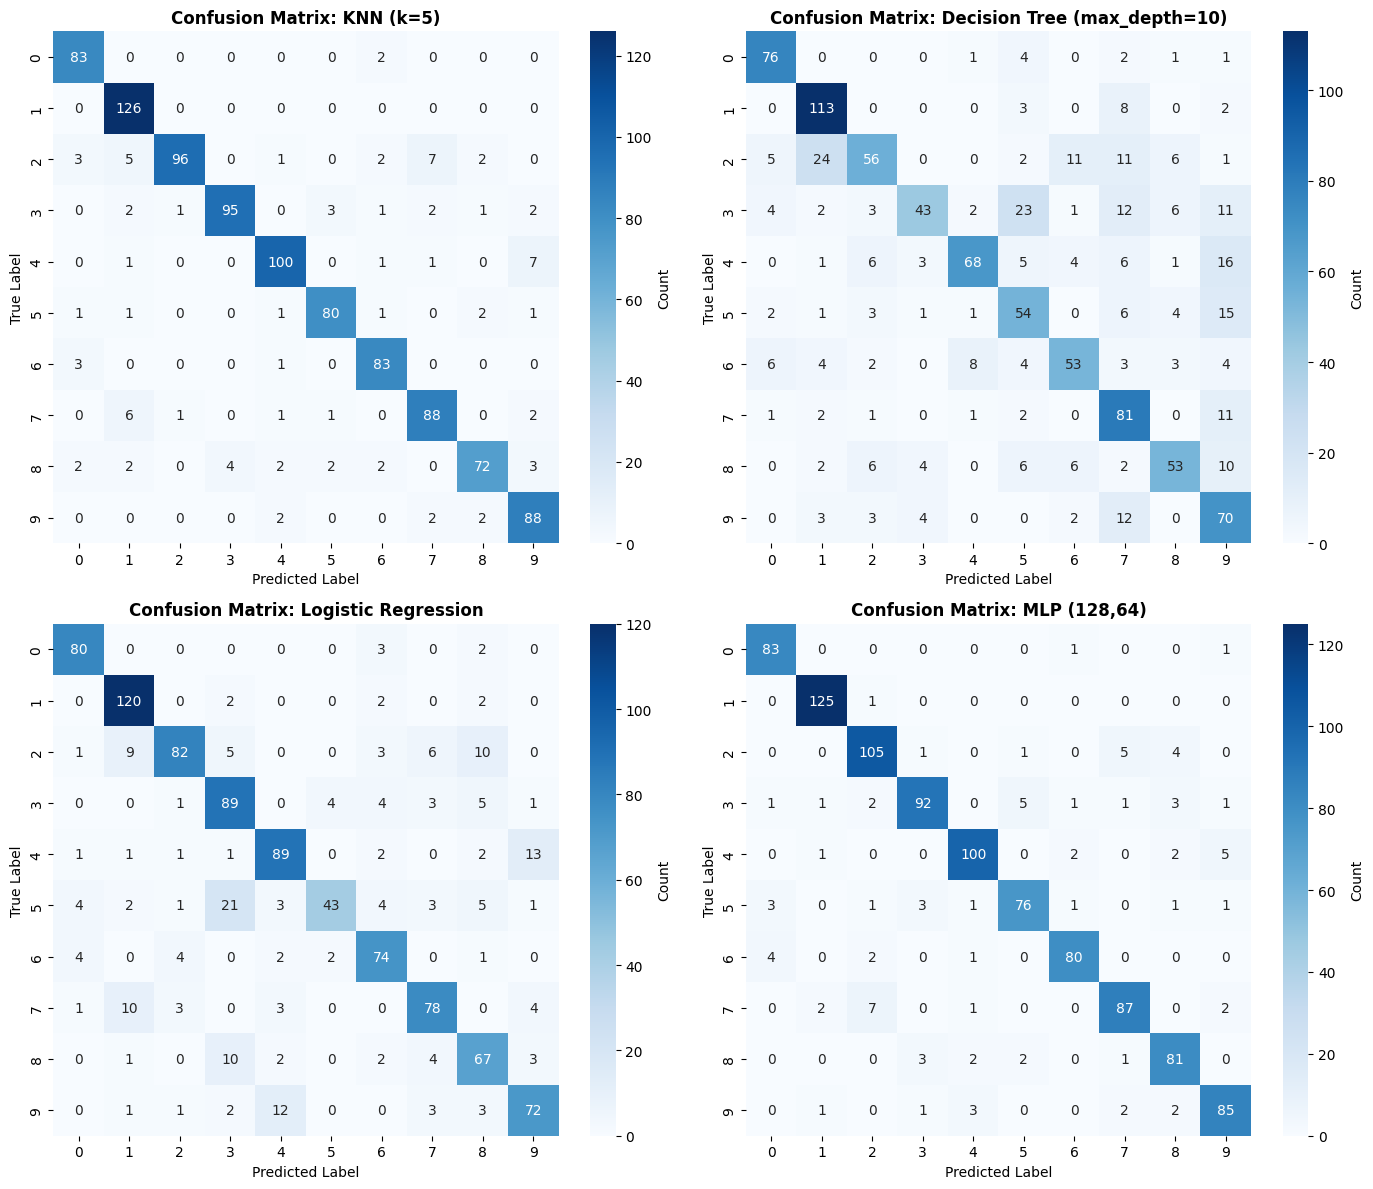

In [28]:
# Create confusion matrices
def create_confusion_matrix_manual(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label][pred_label] += 1
    
    return cm

cm_knn = create_confusion_matrix_manual(y_test_proc, y_pred_knn, num_classes=10)
cm_dt = create_confusion_matrix_manual(y_test_proc, y_pred_dt, num_classes=10)
cm_lr = create_confusion_matrix_manual(y_test_proc, y_pred_lr, num_classes=10)
cm_mlp = create_confusion_matrix_manual(y_test_proc, y_pred_mlp, num_classes=10)

# Stored in dictionary for easy access
confusion_matrices = {
    'KNN (k=5)': cm_knn,
    'Decision Tree (max_depth=10)': cm_dt,
    'Logistic Regression': cm_lr,
    'MLP (128,64)': cm_mlp
}

# Create heatmap visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (algo_name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=range(10), yticklabels=range(10),
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'Confusion Matrix: {algo_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()    
